# DBSCAN Clustering Implementation
This notebook demonstrates the implementation of the Density-Based Spatial Clustering of Applications with Noise (DBSCAN) algorithm.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Generate Dummy Data

Let's create a simple dataset with a few distinct clusters and some noise for demonstration purposes.

In [6]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, centers=[[1,1], [-1,-1], [1,-1], [-2,2]], cluster_std=0.4, random_state=42)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])

print("First 5 rows of the generated data:")
display(df.head())

First 5 rows of the generated data:


,feature_1,feature_2
0,-1.476521,-0.737379
1,0.782247,1.044369
2,1.048118,-0.794224
3,-1.392603,-0.815159
4,-0.976717,-1.457188


### 2. Preprocess Data (Scaling)

DBSCAN is a distance-based algorithm, so it's sensitive to the scale of the features. It's good practice to scale the data before applying DBSCAN.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("First 5 rows of the scaled data:")
display(pd.DataFrame(X_scaled, columns=df.columns).head())

First 5 rows of the scaled data:


,feature_1,feature_2
0,-0.905047,-0.740851
1,0.767575,0.604894
2,0.964453,-0.783787
3,-0.842905,-0.799598
4,-0.534940,-1.284520


### 3. Apply DBSCAN Clustering

Now, let's apply the DBSCAN algorithm. You'll need to choose appropriate values for `eps` (maximum distance between two samples for one to be considered as in the neighborhood of the other) and `min_samples` (the number of samples in a neighborhood for a point to be considered as a core point).

In [7]:
dbsc = DBSCAN(eps=0.3, min_samples=5)
clusters = dbsc.fit_predict(X_scaled)

df['cluster'] = clusters

print("Cluster labels assigned:")
display(df['cluster'].value_counts())

Cluster labels assigned:


,count
cluster,
1,74
3,74
2,73
0,72
-1,7


### 4. Visualize the Clusters

Finally, let's visualize the results to see the identified clusters. Noise points are typically assigned a cluster label of -1.

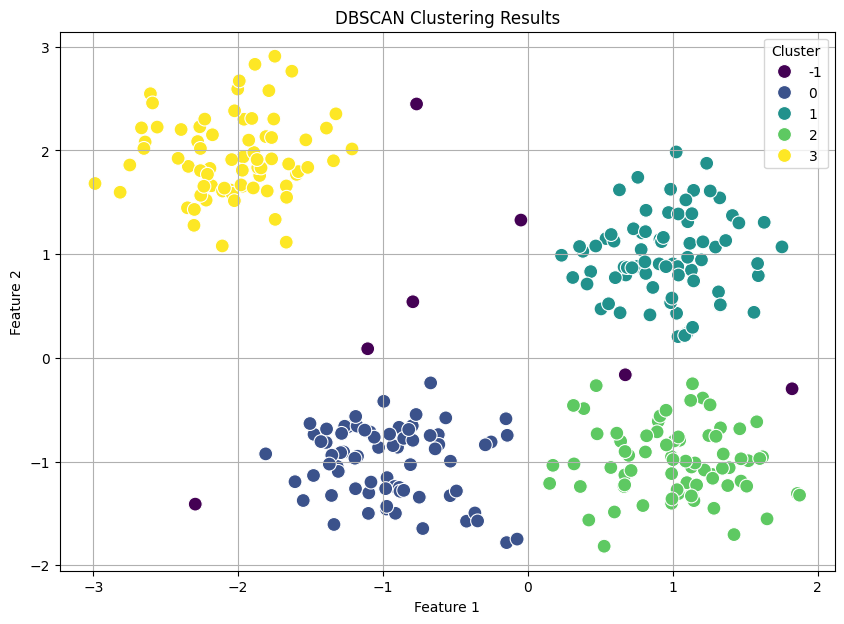

In [5]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='feature_1', y='feature_2', hue='cluster', data=df, palette='viridis', s=100)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()